In [1]:
print ("Hi")

Hi


In [2]:
y = "julius"
print (y)

julius


In [3]:
type(y)

str

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
path = r"C:\Users\Admin\Downloads\archive.zip"

In [5]:
df=pd.read_csv(path)

In [6]:
df.head

<bound method NDFrame.head of       product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category discounted_price  \
0     Computers&Accessories|Accessories&P

In [7]:
df.shape

(1465, 16)

df.describe

In [8]:
df.tail

<bound method NDFrame.tail of       product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category discounted_price  \
0     Computers&Accessories|Accessories&P

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [10]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [11]:
df["rating_count"].mode()[0]

'9,378'

In [12]:
df["rating_count"] = df["rating_count"].fillna(df["rating_count"].mode()[0])


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1465 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [14]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [15]:
num_str = "9,378"
num = int(num_str.replace(",",""))
print(num)

9378


In [16]:

# 1. Clean and convert numeric columns (Prices, Ratings, Counts)
num_cols = ['discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count']

for col in num_cols:
    # Remove currency symbols, commas, and % signs, then convert to float
    df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. Optimize repeated text (Category)
df['category'] = df['category'].astype('category')

# 3. Ensure everything else is a clean string (Objects)
text_cols = ['product_id', 'product_name', 'about_product', 'user_id', 
             'user_name', 'review_id', 'review_title', 'review_content']

for col in text_cols:
    df[col] = df[col].astype(str)

# Verify the changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   product_id           1465 non-null   object  
 1   product_name         1465 non-null   object  
 2   category             1465 non-null   category
 3   discounted_price     1465 non-null   float64 
 4   actual_price         1465 non-null   float64 
 5   discount_percentage  1465 non-null   int64   
 6   rating               1464 non-null   float64 
 7   rating_count         1465 non-null   int64   
 8   about_product        1465 non-null   object  
 9   user_id              1465 non-null   object  
 10  user_name            1465 non-null   object  
 11  review_id            1465 non-null   object  
 12  review_title         1465 non-null   object  
 13  review_content       1465 non-null   object  
 14  img_link             1465 non-null   object  
 15  product_link         

In [17]:
# fundind out if there are mis`sing values in the cleaned/trnform,ed data set
df.isnull().sum()
df= df.dropna()

In [18]:
df.duplicated().sum()
df= df.drop_duplicates()

In [19]:
#check if the null values where dropped

df.isnull().sum()


product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

# ACTUAL EDA

In [20]:
df.describe

<bound method NDFrame.describe of       product_id                                       product_name  \
0     B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1     B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2     B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3     B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4     B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   
...          ...                                                ...   
1460  B08L7J3T31  Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...   
1461  B01M6453MB  Prestige Delight PRWO Electric Rice Cooker (1 ...   
1462  B009P2LIL4  Bajaj Majesty RX10 2000 Watts Heat Convector R...   
1463  B00J5DYCCA  Havells Ventil Air DSP 230mm Exhaust Fan (Pist...   
1464  B01486F4G6  Borosil Jumbo 1000-Watt Grill Sandwich Maker (...   

                                               category  discounted_price  \
0     Computers&Accessories|Accessor

In [21]:
df["discounted_price"].mean()

np.float64(3126.0119057377046)

In [22]:
df[["discounted_price","actual_price","discount_percentage","rating","rating_count"]].describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1464.000000,1464.000000,1464.000000,1464.000000,1464.000000
mean,3126.011906,5447.002923,47.713115,4.096585,18295.178279
std,6946.625442,10878.270001,21.627422,0.291674,42738.128282
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,323.750000,800.000000,32.000000,4.000000,1192.500000
50%,799.000000,1650.000000,50.000000,4.100000,5187.000000
75%,1999.000000,4303.750000,63.000000,4.300000,17330.750000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


In [23]:
#DISCOUNT PERCENTAGES LOOK HIGH
# Show products with discount >= 80%
df[df["discount_percentage"] >= 80][["product_name", "actual_price", "discounted_price", "discount_percentage"]].sort_values("discount_percentage", ascending=False)

,product_name,actual_price,discounted_price,discount_percentage
695,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",4999.0,294.0,94
334,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",19999.0,1799.0,91
380,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",19999.0,1799.0,91
372,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",19999.0,1799.0,91
368,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",19999.0,1799.0,91
...,...,...,...,...
623,Sounce Fast Phone Charging Cable & Data Sync U...,999.0,199.0,80
630,"SYVO WT 3130 Aluminum Tripod (133CM), Universa...",3990.0,799.0,80
635,Tygot Bluetooth Extendable Selfie Sticks with ...,1999.0,399.0,80
656,Boult Audio Probass Curve Bluetooth Wireless i...,4499.0,899.0,80


In [24]:
# How many products have 80%+ discount?
print(df[df["discount_percentage"] >= 80].shape[0])

# What % of the dataset is that?
print(df[df["discount_percentage"] >= 80].shape[0] / len(df) * 100)

96
6.557377049180328


In [25]:
df["main_category"] = df["category"].str.split("|").str[0]
df["main_category"].value_counts()

main_category
Electronics              526
Computers&Accessories    453
Home&Kitchen             447
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64

In [26]:
df["estimated_revenue"] = df["discounted_price"] * df["rating_count"]

df.groupby("main_category")["estimated_revenue"].sum().sort_values(ascending=False)

main_category
Electronics              5.917975e+10
Computers&Accessories    6.358770e+09
Home&Kitchen             6.262254e+09
MusicalInstruments       6.445808e+07
OfficeProducts           4.578673e+07
Health&PersonalCare      3.293037e+06
Car&Motorbike            2.615002e+06
HomeImprovement          2.587190e+06
Toys&Games               2.380050e+06
Name: estimated_revenue, dtype: float64

In [27]:
revenue_by_cat = df.groupby("main_category")["estimated_revenue"].sum().sort_values(ascending=False)

# Display in billions, readable format
for cat, rev in revenue_by_cat.items():
    print(f"{cat:<25} ₹{rev/1e9:.2f}B")

Electronics               ₹59.18B
Computers&Accessories     ₹6.36B
Home&Kitchen              ₹6.26B
MusicalInstruments        ₹0.06B
OfficeProducts            ₹0.05B
Health&PersonalCare       ₹0.00B
Car&Motorbike             ₹0.00B
HomeImprovement           ₹0.00B
Toys&Games                ₹0.00B


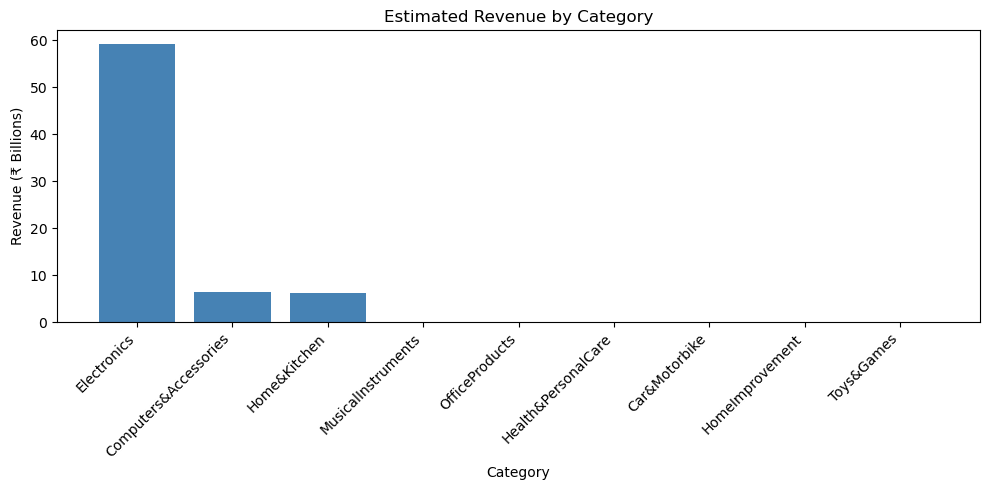

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(revenue_by_cat.index, revenue_by_cat.values / 1e9, color="steelblue")
plt.title("Estimated Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹ Billions)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

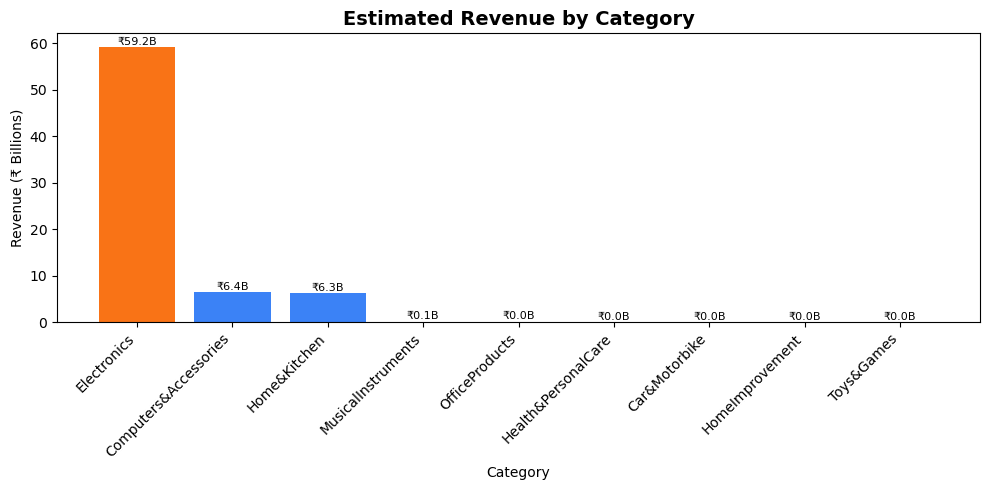

In [29]:
colors = ["#F97316" if i == 0 else "#3B82F6" for i in range(len(revenue_by_cat))]

plt.figure(figsize=(10, 5))
plt.bar(revenue_by_cat.index, revenue_by_cat.values / 1e9, color=colors)
plt.title("Estimated Revenue by Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Revenue (₹ Billions)")
plt.xticks(rotation=45, ha="right")

# Add value labels on top of each bar
for i, (cat, val) in enumerate(revenue_by_cat.items()):
    plt.text(i, val/1e9 + 0.5, f"₹{val/1e9:.1f}B", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

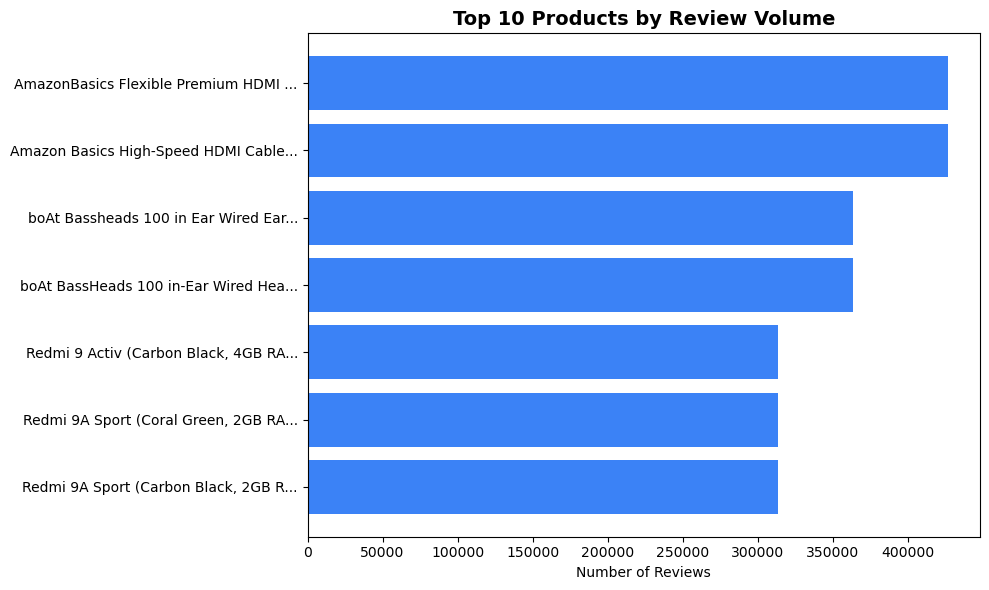

In [30]:
top10 = df.nlargest(10, "rating_count")[["product_name", "main_category", "discounted_price", "rating", "rating_count"]]

# Shorten long product names for the chart
top10["short_name"] = top10["product_name"].str[:35] + "..."

plt.figure(figsize=(10, 6))
plt.barh(top10["short_name"], top10["rating_count"], color="#3B82F6")
plt.title("Top 10 Products by Review Volume", fontsize=14, fontweight="bold")
plt.xlabel("Number of Reviews")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

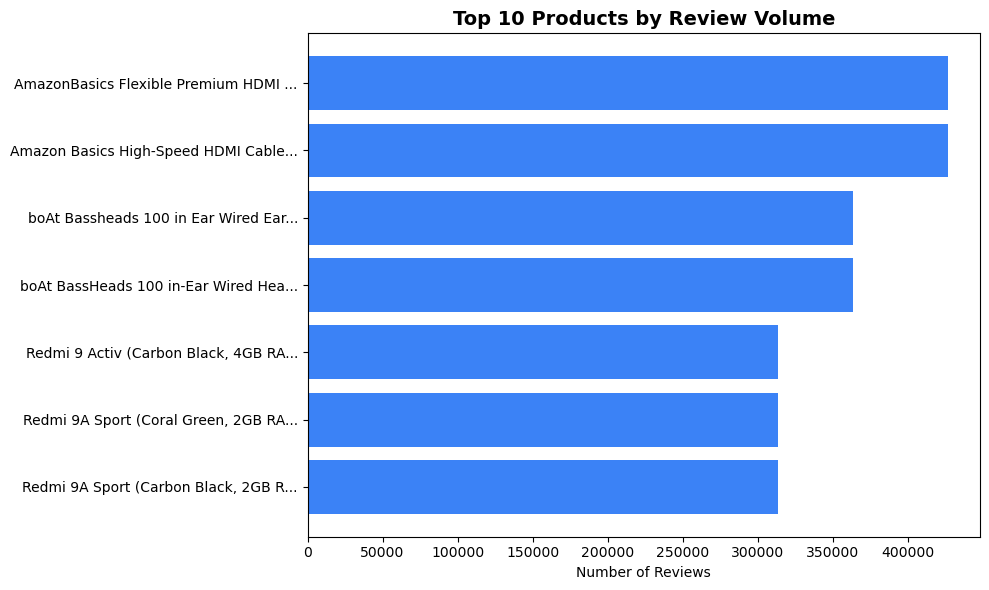

In [31]:
top10 = df.nlargest(10, "rating_count")[["product_name", "main_category", "discounted_price", "rating", "rating_count"]]

top10["short_name"] = top10["product_name"].str[:35] + "..."

plt.figure(figsize=(10, 6))
plt.barh(top10["short_name"], top10["rating_count"], color="#3B82F6")
plt.title("Top 10 Products by Review Volume", fontsize=14, fontweight="bold")
plt.xlabel("Number of Reviews")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

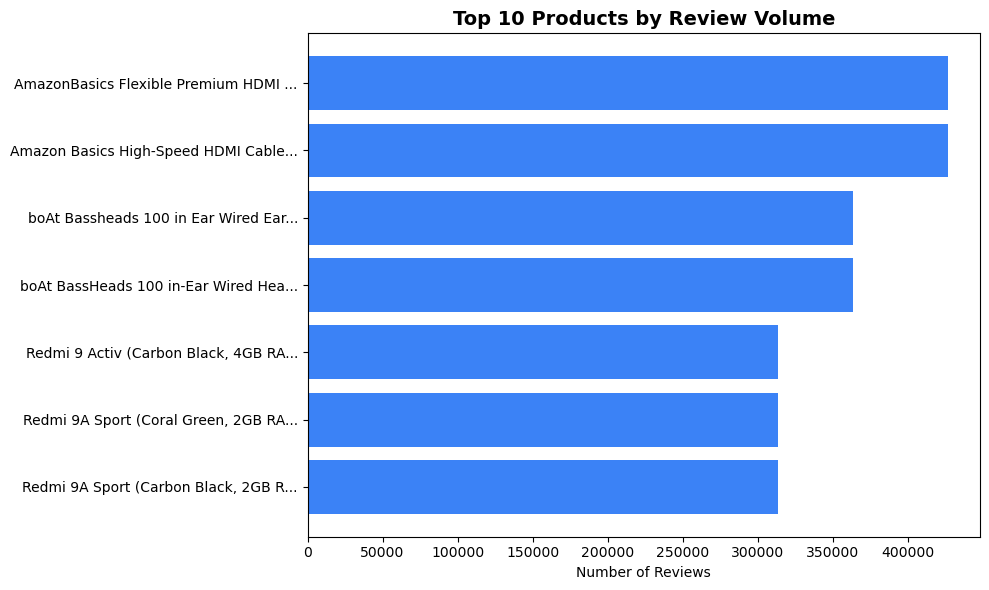

In [32]:
top10 = df.nlargest(10, "rating_count")[["product_name", "main_category", "discounted_price", "rating", "rating_count"]]

top10["short_name"] = top10["product_name"].str[:35] + "..."

plt.figure(figsize=(10, 6))
plt.barh(top10["short_name"], top10["rating_count"], color="#3B82F6")
plt.title("Top 10 Products by Review Volume", fontsize=14, fontweight="bold")
plt.xlabel("Number of Reviews")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

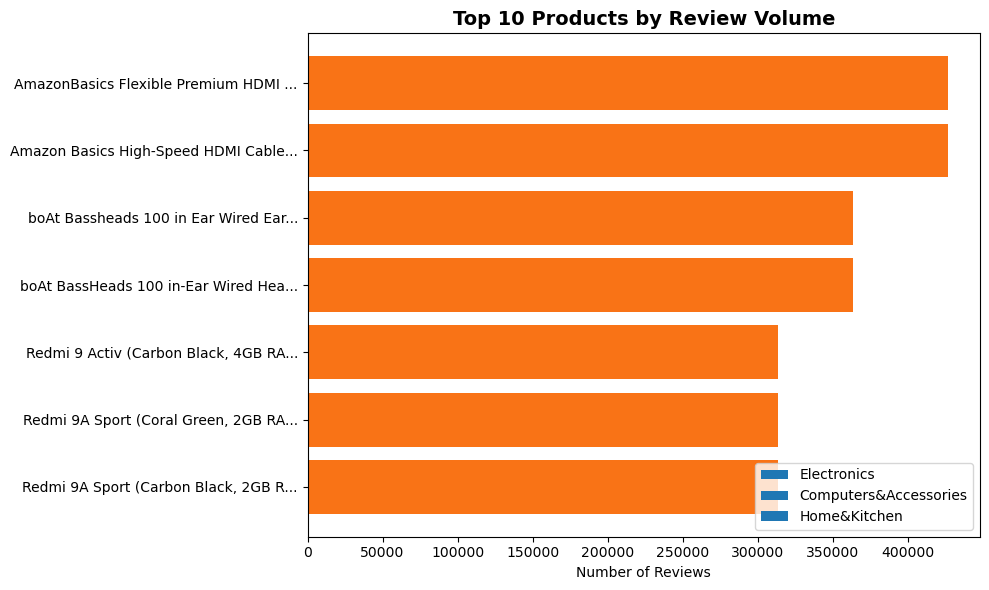

In [33]:
# Map categories to colours
cat_colors = {
    "Electronics": "#F97316",
    "Computers&Accessories": "#3B82F6",
    "Home&Kitchen": "#10B981"
}

colors = top10["main_category"].map(cat_colors).fillna("#8B5CF6")

plt.figure(figsize=(10, 6))
plt.barh(top10["short_name"], top10["rating_count"], color=colors)
plt.title("Top 10 Products by Review Volume", fontsize=14, fontweight="bold")
plt.xlabel("Number of Reviews")
plt.gca().invert_yaxis()

# Add legend
for cat, color in cat_colors.items():
    plt.barh([], [], color=color, label=cat)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

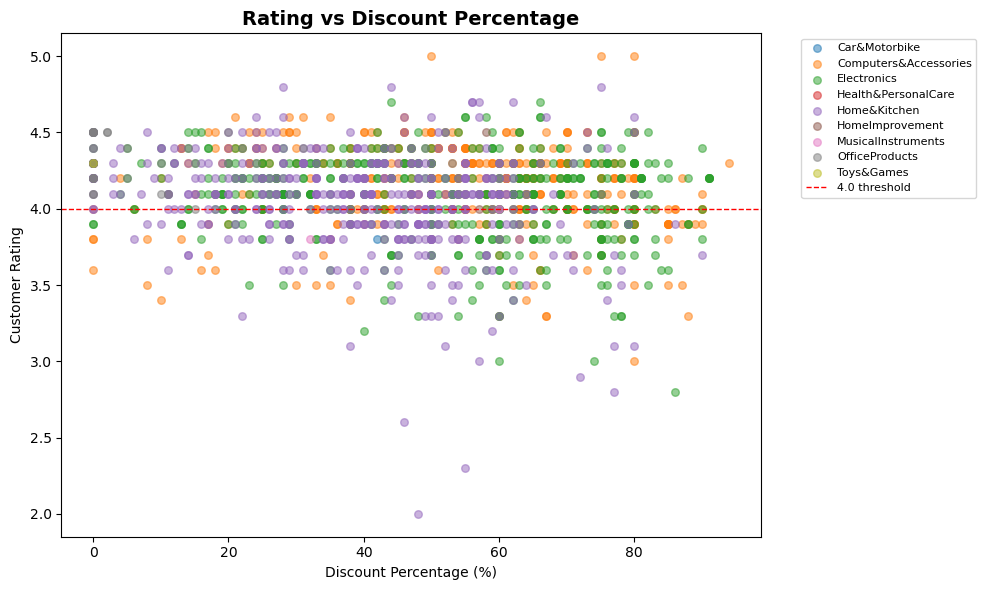

In [34]:
plt.figure(figsize=(10, 6))

for cat, group in df.groupby("main_category"):
    plt.scatter(
        group["discount_percentage"],
        group["rating"],
        alpha=0.5,
        s=30,
        label=cat
    )

plt.title("Rating vs Discount Percentage", fontsize=14, fontweight="bold")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Customer Rating")
plt.axhline(4.0, color="red", linestyle="--", linewidth=1, label="4.0 threshold")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [35]:
print("Avg rating:", df["rating"].mean().round(2))
print("% products above 4.0 rating:", round((df["rating"] >= 4.0).sum() / len(df) * 100, 1))
print("Most common discount range:")
print(pd.cut(df["discount_percentage"], bins=[0,20,40,60,80,100]).value_counts().sort_index())

Avg rating: 4.1
% products above 4.0 rating: 75.8
Most common discount range:
discount_percentage
(0, 20]      130
(20, 40]     338
(40, 60]     508
(60, 80]     380
(80, 100]     59
Name: count, dtype: int64


## 📊 Business Insights & Recommendations

### Dataset Overview
- 1,464 products analysed across 9 categories
- Average selling price: ₹3,126 | Average original price: ₹5,447
-Average discount: 47.7% | Average customer rating: 4.1/5.0



### Insight 1 — Electronics Dominates Revenue
Electronics generates ₹59.2B in estimated revenue — nearly 10x more than 
Computers & Accessories (₹6.4B) and Home & Kitchen (₹6.3B).
This single category accounts for approximately 85% of total estimated revenue.

Recommendation: Prioritise expanding the Electronics catalogue. 
More SKUs in this category directly translates to more revenue opportunity.

### Insight 2 — Accessories Are the Volume Kings
The top 10 most-reviewed products are all Electronics:
AmazonBasics HDMI cables (400K+ reviews each) and boAt earphones (360K+ reviews).
These are low-cost, high-demand products that drive massive order volumes.

Recommendation: Use high-volume accessories as entry points — 
bundle them with premium products to increase average order value.



### Insight 3 — Discounts Don't Hurt Quality Perception
75.8% of products maintain a rating above 4.0 regardless of discount level.
The scatter plot shows no meaningful relationship between discount depth and rating.
The most common discount bracket is 41–60% (508 products).

Recommendation: The 40–60% discount range is the sweet spot — 
it drives volume without signalling low quality to customers.


### Insight 4 — Home & Kitchen Is Underperforming
Home & Kitchen has nearly as many products as Electronics (447 vs 526) 
but generates only ₹6.3B vs ₹59.2B — a 90% revenue gap.

Recommendation: Either reprice Home & Kitchen products upward, 
or invest in higher-demand SKUs in that category to close the gap.


### Risk Flag ⚠️
96 products (6.6% of catalogue) carry discounts above 80%.
These likely have artificially inflated original prices — 
a common tactic that can mislead customers and damage long-term trust.

Recommendation: Audit these listings and apply a discount cap policy of 80%.

# DASH Board

In [37]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


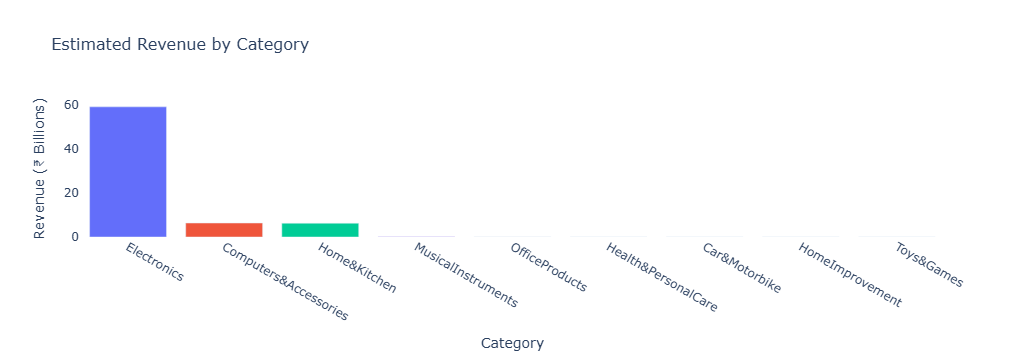

In [38]:
import plotly.express as px

fig1 = px.bar(
    x=revenue_by_cat.index,
    y=revenue_by_cat.values / 1e9,
    labels={"x": "Category", "y": "Revenue (₹ Billions)"},
    title="Estimated Revenue by Category",
    color=revenue_by_cat.index,
)

fig1.update_layout(
    plot_bgcolor="white",
    showlegend=False,
    title_font_size=16,
)

fig1.show()

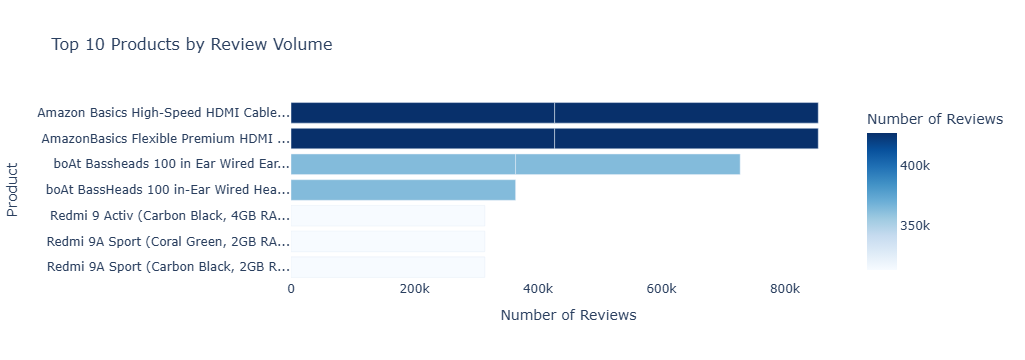

In [39]:
fig2 = px.bar(
    top10.iloc[::-1],
    x="rating_count",
    y="short_name",
    orientation="h",
    title="Top 10 Products by Review Volume",
    labels={"rating_count": "Number of Reviews", "short_name": "Product"},
    color="rating_count",
    color_continuous_scale="Blues",
)

fig2.update_layout(
    plot_bgcolor="white",
    title_font_size=16,
    showlegend=False,
)

fig2.show()

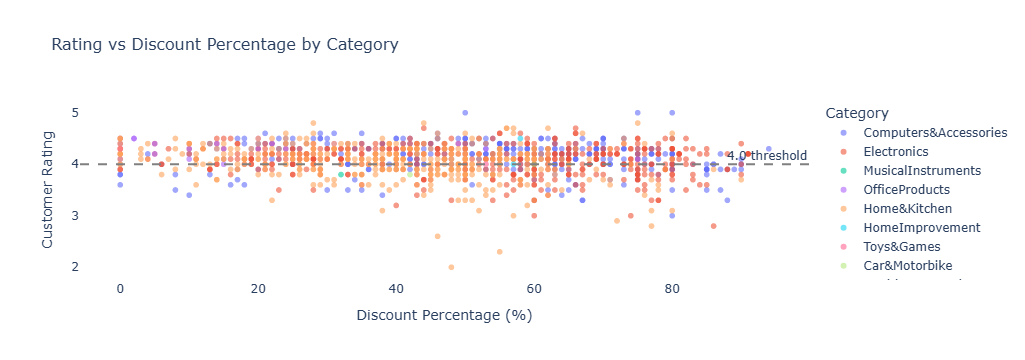

In [40]:
fig3 = px.scatter(
    df,
    x="discount_percentage",
    y="rating",
    color="main_category",
    title="Rating vs Discount Percentage by Category",
    labels={
        "discount_percentage": "Discount Percentage (%)",
        "rating": "Customer Rating",
        "main_category": "Category"
    },
    hover_data=["product_name", "discounted_price"],
    opacity=0.6,
)

fig3.add_hline(
    y=4.0,
    line_dash="dash",
    line_color="gray",
    annotation_text="4.0 threshold",
    annotation_position="top right"
)

fig3.update_layout(
    plot_bgcolor="white",
    title_font_size=16,
)

fig3.show()